# Theory-agnostic nonclassicality certification in an integrated photonics circuit 

This notebook accompanies [] and contains all functions and data required to obtain the numerical results therein. It is divided into 3 Sections, which respectively: define the linear program to assess contextuality in prepare-and-measure scenarios (introduced in [Phys. Rev. Lett. 132, 050202 (2024)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.132.050202) and adapted from [https://github.com/RossiVinicius/SimplexEmbeddingGPT-v2](https://github.com/RossiVinicius/SimplexEmbeddingGPT-v2)); define the functions for theory-agnostic tomography (following the methods of [Nat. Commun. 17, 2474 (2026)](https://www.nature.com/articles/s41467-026-69030-x) and adapted from [https://github.com/Albert-Aloy/NonclassicalityTests](https://github.com/Albert-Aloy/NonclassicalityTests)); and the functions that concern the specifics of this paper.

## Requirements and installation

This notebook was developed and tested with Python 3.11. The main dependencies are `numpy`, `scipy`, `sympy`, `matplotlib`, `cvxpy`, `cvxopt`, `pycddlib`, and the solver `MOSEK`. 

Notice that installing `pycddlib` might require installing additional compilers (especially in Linux systems) or Python development headers (if installing from source). See the documentation at [https://pycddlib.readthedocs.io/en/latest/quickstart.html#installation](https://pycddlib.readthedocs.io/en/latest/quickstart.html#installation) for more information.

Our assessments of nonclassicality rely on solving a linear program with the use of `MOSEK`. This is a private solver that may require a license. While this might jeopardise reproductibility of results, this solver is strongly recommended for numerical stability and speed. It can be installed following the instructions from [https://www.mosek.com/](https://www.mosek.com/). Alternative free solvers might achieve similar results, but we cannot ensure full reproductibility in that case.

To install the requirements, run

```
pip install numpy scipy sympy matplotlib cvxpy cvxopt pycddlib mosek
```
if using `pip`.

## Imports

In [30]:
# General imports--------------------------------------------------------------------------
import numpy as np

# Imports for nonclassicality certification -----------------------------------------------
from itertools import product
from sympy import Rational
import cdd.gmp as cdd
import re
import cvxpy as cp
from scipy.linalg import lu
from scipy.sparse import csr_matrix

# Imports for theory-agnostic tomography -------------------------------------------------
import os
import csv
import scipy as sp
import cvxopt  as cv
import scipy.linalg
import scipy.optimize

# Imports for plotting -------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

## Nonclassicality certification - core functions
This section documents the core functions used to certify nonclassicality in a theory-agnostic way, following the framework of generalised non-contextuality in Generalised Probabilistic Theories (GPTs).

The pipeline can be summarised as:

1. *Accessible GPT fragment* — Identify the subspace actually spanned by the experimental states and effects.
2. *Cone facets* — Compute the facets of the state and effect positive cones.
3. *Simplex embedding* — Solve a linear program to test whether a non-contextual ontological model exists, and if not, quantify the robustness of nonclassicality.

### Mathematical tools

The RREF of a matrix is used to identify the independent rows of the state/effect matrices, which determines the dimension of the accessible GPT fragment. Concretely, the non-zero rows of `rref(S.T)` give the inclusion map into the accessible fragment.

In [19]:
def rref(B, tol=1e-8, debug=False):
    """
    Computes the Reduced Row Echelon Form (RREF) of a matrix.

    Uses partial pivoting for numerical stability. Entries with absolute
    value below `tol` are treated as zero.

    Args:
        B (np.ndarray): Input matrix of shape (m, n).
        tol (float): Numerical zero threshold. Default 1e-8.
        debug (bool): If True, prints intermediate steps. Default False.

    Returns:
        np.ndarray: RREF of B, shape (m, n).

    © 2017 Stelios Sfakianakis (https://gist.github.com/sgsfak/77a1c08ac8a9b0af77393b24e44c9547).
    """
    A = B.copy()
    rows, cols = A.shape
    r = 0
    pivots_pos = []
    row_exchanges = np.arange(rows)
    for c in range(cols):
        if debug:
            print("Now at row", r, "and col", c, "with matrix:")
            print(A)
        pivot = np.argmax(np.abs(A[r:rows, c])) + r
        m = np.abs(A[pivot, c])
        if debug:
            print("Found pivot", m, "in row", pivot)
        if m <= tol:
            A[r:rows, c] = np.zeros(rows - r)
            if debug:
                print("All elements at and below (", r, ",", c, ") are zero.. moving on..")
        else:
            pivots_pos.append((r, c))
            if pivot != r:
                A[[pivot, r], c:cols] = A[[r, pivot], c:cols]
                row_exchanges[[pivot, r]] = row_exchanges[[r, pivot]]
                if debug:
                    print("Swap row", r, "with row", pivot, "Now:")
                    print(A)
            A[r, c:cols] = A[r, c:cols] / A[r, c]
            v = A[r, c:cols]
            if r > 0:
                ridx_above = np.arange(r)
                A[ridx_above, c:cols] = (
                    A[ridx_above, c:cols] - np.outer(v, A[ridx_above, c]).T
                )
                if debug:
                    print("Elimination above performed:")
                    print(A)
            if r < rows - 1:
                ridx_below = np.arange(r + 1, rows)
                A[ridx_below, c:cols] = (
                    A[ridx_below, c:cols] - np.outer(v, A[ridx_below, c]).T
                )
                if debug:
                    print("Elimination below performed:")
                    print(A)
            r += 1
        if r == rows:
            break
    return A

The state and effect cones are polyhedral cones. Their facets (the half-space inequalities $H_S$, $H_E$) are needed to set up the simplex embedding linear program.
- The state cone is given in generator (V-representation) form — cdd converts it to the inequality (H-representation).
- The effect cone is given in inequality (H-representation) form — cdd converts it to generators (V-representation).

Exact rational arithmetic (`cdd.gmp`) is used to avoid numerical errors from floating-point vertex enumeration.

In [20]:
def FindStateConeFacets(S):
    """
    Computes the facets (H-representation) of the positive cone spanned by the
    states in the accessible GPT fragment.

    Converts the state matrix (V-representation) to exact rational form and uses
    the cdd library (exact GMP arithmetic) to enumerate the bounding half-spaces.

    Args:
        S (np.ndarray): State vectors in the accessible fragment.
            shape = (accessible_dim, num_states)

    Returns:
        np.ndarray: Facet inequalities H_S.
            shape = (num_facets, accessible_dim)
            Each row h satisfies h @ s >= 0 for all valid states s.
    """
    S = np.array([[Rational(x).limit_denominator() for x in row] for row in S])
    C = cdd.matrix_from_array(S.T)
    C.rep_type = cdd.RepType.GENERATOR
    H_S = cdd.copy_inequalities(cdd.polyhedron_from_matrix(C))
    H_S = np.array(H_S.array, dtype=np.float64)
    H_S[np.abs(H_S) < 1e-6] = 0
    return H_S


def FindEffectConeFacets(E):
    """
    Computes the generators (V-representation) of the positive cone dual to the
    effects in the accessible GPT fragment.

    Converts the effect matrix (H-representation) to exact rational form and uses
    the cdd library (exact GMP arithmetic) to enumerate the extreme rays.

    Args:
        E (np.ndarray): Effect vectors in the accessible fragment.
            shape = (accessible_dim, num_effects)

    Returns:
        np.ndarray: Effect cone generators H_E.
            shape = (accessible_dim, num_generators)
    """
    E = np.array([[Rational(x).limit_denominator() for x in row] for row in E])
    C = cdd.matrix_from_array(E.T)
    C.rep_type = cdd.RepType.INEQUALITY
    return np.array(
        cdd.copy_generators(cdd.polyhedron_from_matrix(C)).array, dtype=np.float64
    ).T

### Simplex embedding

Given the matrix of state vectors $S$, we find its row space via RREF, then define:

- Inclusion map $I_S$: embeds the accessible fragment back into the full space.
- Projection map $P_S$: projects full-space vectors down to the fragment.

The same can be done for the matrix of effect vectors $E$ and the respective inclusion $I_E$ and projection $P_E$.

In [21]:
def DefineAccessibleGPTFragment(statesOrEffects, tol=1e-7):
    """
    Identifies the accessible GPT fragment spanned by a given set of states or effects.

    Uses RREF to find a basis for the row space, then computes the inclusion and
    projection maps between the full GPT space and the accessible fragment.

    Args:
        statesOrEffects (np.ndarray): State or effect vectors.
            shape = (full_gpt_dim, num_vectors)
        tol (float): Threshold for identifying zero singular values. Default 1e-7.

    Returns:
        tuple:
            - inclusionMap (np.ndarray): Maps accessible fragment -> full space.
                shape = (full_gpt_dim, accessible_dim)
            - projectionMap (np.ndarray): Maps full space -> accessible fragment.
                shape = (accessible_dim, full_gpt_dim)
            - accessibleFragment (np.ndarray): Vectors projected into the fragment.
                shape = (accessible_dim, num_vectors)
    """
    REF = rref(statesOrEffects.T)

    P, L, U = lu(statesOrEffects)
    r = len(np.unique(csr_matrix(U).indptr)) - 1

    inclusionMap = REF[:r, :].T
    projectionMap = np.linalg.pinv(inclusionMap.T @ inclusionMap) @ inclusionMap.T

    return inclusionMap, projectionMap, projectionMap @ statesOrEffects

A GPT fragment is classically explainable (non-contextual) if and only if its state and effect cones can be jointly embedded into a simplicial (classical) cone — i.e., a non-contextual ontological model exists [PRX Quantum 2, 010331 (2021)]. Following Linear Program of [PRL 132, 050202 (2024)], we test this by asking: does there exist a non-negative matrix $\sigma$ such that
$$(1-r) I_E^T\cdot I_S +r D = H_E^T\cdot\sigma\cdot H_S$$

where $D$ is the maximally depolarising channel in this accessible fragment and $r$ is the robustness of contextuality, i.e., the minimum depolarising noise needed to make the fragment classically explainable. A value of $r=0$ means the data is already classical; $r>0$ certifies nonclassicality.

In [22]:
def SimplicialConeEmbedding(H_S, H_E, accessibleFramentBornRule, depolarizingMap):
    """
    Solves the simplex-embedding linear program (LP 2 of Selby et al. 2024) to test
    whether a non-contextual ontological model exists for the accessible GPT fragment,
    and if not, computes the robustness of contextuality to depolarising noise.

    The LP minimises r >= 0 subject to:
        r * depolarizingMap + (1 - r) * BornRule = H_E @ sigma @ H_S
    with sigma >= 0 element-wise.

    Args:
        H_S (np.ndarray): State cone facets.
            shape = (num_state_facets, accessible_state_dim)
        H_E (np.ndarray): Effect cone generators.
            shape = (accessible_effect_dim, num_effect_generators)
        accessibleFramentBornRule (np.ndarray): Bilinear form encoding the Born rule
            in the accessible fragment: iota_E.T @ iota_S.
            shape = (accessible_state_dim, accessible_effect_dim)
        depolarizingMap (np.ndarray): Outer product of the unit effect and the
            maximally mixed state in the accessible fragment.
            shape = (accessible_effect_dim, accessible_state_dim)

    Returns:
        tuple:
            - robustness (float): Minimum depolarising noise for classical explainability.
              r = 0 means the data is classical; r > 0 certifies nonclassicality.
            - sigma (np.ndarray): Optimal sigma matrix from the LP.
                shape = (num_effect_generators, num_state_facets)
    """
    robustness, sigma = cp.Variable(nonneg=True), cp.Variable(
        shape=(H_E.shape[1], H_S.shape[0]), nonneg=True
    )

    problem = cp.Problem(
        cp.Minimize(robustness),
        [
            robustness * depolarizingMap
            + (1 - robustness) * accessibleFramentBornRule
            - H_E @ sigma @ H_S
            == 0
        ],
    )

    problem.solve(solver=cp.MOSEK, verbose=False)
    return robustness.value, sigma.value

def SimplexEmbedding(states, effects, unit, mms):
    """
    Top-level function: tests whether the given GPT fragment admits a non-contextual
    ontological model, and quantifies the robustness of nonclassicality if not.

    Orchestrates the full pipeline:
        1. Compute accessible GPT fragments for states and effects.
        2. Find the positive cone facets for each fragment.
        3. Build the Born rule bilinear form and the depolarising map.
        4. Solve the simplex-embedding LP.

    Args:
        states (np.ndarray): State vectors in the full GPT space.
            shape = (gpt_dim, num_states)
        effects (np.ndarray): Effect vectors in the full GPT space.
            shape = (gpt_dim, num_effects)
        unit (np.ndarray): Unit effect vector (image of the identity operator).
            shape = (gpt_dim,)
        mms (np.ndarray): Maximally mixed state vector (image of identity/d).
            shape = (gpt_dim,)

    Returns:
        float: Robustness of contextuality r.
            r = 0  -> data is classically explainable (non-contextual).
            r > 0  -> data is nonclassical; r is the minimum depolarising noise
                      needed to destroy the nonclassicality.
    """
    inclusion_S, projection_S, accessibleFragmentStates = DefineAccessibleGPTFragment(states)
    inclusion_E, projection_E, accessibleFragmentEffects = DefineAccessibleGPTFragment(effects)

    accessibleFragmentUnit = projection_E @ unit
    accessibleFragmentMMS  = projection_S @ mms

    H_S = FindStateConeFacets(accessibleFragmentStates)
    H_E = FindEffectConeFacets(accessibleFragmentEffects)

    accessibleFragmentBornRule = inclusion_E.T @ inclusion_S
    depolarizingMap = np.outer(accessibleFragmentUnit, accessibleFragmentMMS)

    robustness, sigma = SimplicialConeEmbedding(
        H_S, H_E, accessibleFragmentBornRule, depolarizingMap
    )
    return robustness

## Theory-agnostic tomography - core functions

This section defines the functions used to perform theory-agnostic tomography on a prepare-and-measure data table, following [Nat. Comm. 17, 2474 (2026)](https://doi.org/10.1038/s41467-025-57581-5) and adapted from [https://github.com/Albert-Aloy/NonclassicalityTests]. For a detailing of each function, see the original GitHub repository.

Given a frequency matrix `data` of shape `(num_preparations, num_effects)`, the goal is to find a factorisation $D \approx S^T E$ of rank $k$ that minimises the $\chi^2$ statistic (Eq. 4 of the paper). This is achieved via a **seesaw algorithm**: the optimisation alternates between a quadratic program over the state space (fixing effects) and one over the effect space (fixing states), until convergence. Running this over a range of ranks then allows identification of the optimal rank $k$ as described in the main paper that accompanies this notebook.

In [8]:
# ── Objective function and variance ───────────────────────────────────────────

def chisquared(quintuple, data, singleshots_number):
    """Computes the chi-squared statistic between the model D = S^T E and the data."""
    D = np.dot(quintuple[0], quintuple[1])
    F = data
    return np.sum(np.multiply(np.power((F - D), 2), oneoverW(F, singleshots_number)))


def oneoverW(datamat, singleshots_number):
    """Returns the inverse variance 1/W for each entry of the frequency matrix,
    estimated from multinomial sampling with `singleshots_number` trials."""
    return singleshots_number / (np.multiply(datamat, 1 - datamat) + 1e-8)


# ── Constraint arrays for the quadratic programs ──────────────────────────────

def create_array(n):
    """Returns a length-n array with a 1 in the first position and zeros elsewhere."""
    arr = np.zeros(n)
    arr[0] = 1
    return arr


def Barray(n, cardinality):
    """Constructs the B constraint array used in the state quadratic program.
    Shape: (cardinality, n * cardinality)."""
    array = np.zeros((cardinality, n * cardinality))
    for i in range(cardinality):
        array[i, n * i] = 1
    return array


def Aarray(n, cardinality):
    """Constructs the A constraint array (normalisation) used in the state quadratic program.
    Shape: (cardinality, n * cardinality)."""
    array = np.hstack((np.eye(cardinality), np.zeros((cardinality, (n - 1) * cardinality))))
    return array


# ── Quadratic programs ────────────────────────────────────────────────────────

def state_optim(eff, data, n, singleshots_number):
    """Solves the QP that minimises chi-squared over the state space for a fixed effect matrix
    and rank n. Returns the optimal state matrix of shape (num_preparations, n)."""
    data_dimensions = data.shape
    cardinality_preparations = data_dimensions[0]
    cardinality_effects = data_dimensions[1]
    cardinality = cardinality_preparations
    Im = np.identity(cardinality_preparations)
    Wprime = np.diag(oneoverW(data, singleshots_number).flatten(('F')))
    Pfunc = cv.matrix(2 * np.dot(np.dot(np.kron(eff, Im), Wprime), np.transpose(np.kron(eff, Im))))
    qfunc = cv.matrix(-2 * np.dot(np.dot(np.kron(eff, Im), Wprime), data.flatten(('F'))))
    hfunc = cv.matrix(np.array([np.ones(cardinality_preparations * cardinality_effects), np.zeros(cardinality_preparations * cardinality_effects)]).reshape(2 * cardinality_preparations * cardinality_effects, 1))
    Gfunc = cv.matrix(np.kron(np.array([[1], [-1]]), np.transpose(np.kron(eff, Im))))
    Afunc = cv.matrix(Aarray(n, cardinality_preparations))
    bfunc = cv.matrix(np.ones([cardinality_preparations, 1]))
    cv.solvers.options['show_progress'] = False
    solfunc = cv.solvers.qp(Pfunc, qfunc, Gfunc, hfunc, Afunc, bfunc)
    return np.array(solfunc['x']).reshape(n, cardinality_preparations).T


def effect_optim_NOAB(state, data, n, singleshots_number):
    """Solves the QP that minimises chi-squared over the effect space for a fixed state matrix
    and rank n (without A/B normalisation constraints). Returns the optimal effect matrix of shape (n, num_effects)."""
    data_dimensions = data.shape
    cardinality_preparations = data_dimensions[0]
    cardinality_effects = data_dimensions[1]
    cardinality = cardinality_preparations
    Im = np.identity(cardinality_effects)
    Wprime = np.diag(oneoverW(data, singleshots_number).flatten(('F')))
    Pefffunc = cv.matrix(2 * np.dot(np.dot(np.transpose(np.kron(Im, state)), Wprime), np.kron(Im, state)))
    qefffunc = cv.matrix(-2 * np.dot(np.dot(np.transpose(np.kron(Im, state)), Wprime), data.flatten(('F'))))
    Gefffunc = cv.matrix(np.kron(np.array([[1], [-1]]), np.kron(Im, state)))
    hefffunc = cv.matrix(np.array([np.ones(cardinality_preparations * cardinality_effects), np.zeros(cardinality_preparations * cardinality_effects)]).reshape(2 * cardinality_preparations * cardinality_effects, 1))
    cv.solvers.options['show_progress'] = False
    solefffunc = cv.solvers.qp(Pefffunc, qefffunc, Gefffunc, hefffunc)
    return np.array(solefffunc['x']).reshape(cardinality_effects, n).T


# ── Seesaw optimisation ───────────────────────────────────────────────────────

def seesaw_optim(func_state_optim, func_effect_optim, quintuple, singleshots_number, convergence_tolerance):
    """Runs the seesaw algorithm for a fixed rank: alternates between `func_state_optim` and
    `func_effect_optim` until the improvement in chi-squared falls below `convergence_tolerance`.
    `quintuple` = [states, effects, prob, data, rank].
    Returns [states, effects, prob, data, rank, chi-squared]."""
    datamat = quintuple[3]
    data_dimensions = datamat.shape
    cardinality_preparations = data_dimensions[0]
    current_states = quintuple[0]
    rank = quintuple[4]
    if np.all(current_states) == 0:
        current_states = np.random.rand(cardinality_preparations, rank)
    previous_chisquared = 1e10
    exitCriteria = 0
    iterations = 0
    while exitCriteria < 1:
        current_effects = func_effect_optim(current_states, datamat, rank, singleshots_number)
        current_states = func_state_optim(current_effects, datamat, rank, singleshots_number)
        prob = np.dot(current_states, current_effects)
        current_chisquared = chisquared([current_states, current_effects, prob, datamat, rank], datamat, singleshots_number)
        iterations += 1
        print("Rank = " + str(rank) + ", iteration = " + str(iterations) + ". Current Chi^2 = " + str(current_chisquared))
        if np.abs(previous_chisquared - current_chisquared) < convergence_tolerance:
            print("Rank = " + str(rank) + ", iteration = " + str(iterations) + ". Converged to Chi^2 = " + str(current_chisquared))
            exitCriteria = 1
        else:
            previous_chisquared = current_chisquared
    prob = np.dot(current_states, current_effects)
    return [current_states, current_effects, prob, quintuple[3], quintuple[4], current_chisquared]


def seesaw_over_range(func_state_optim, func_effect_optim, datamat, first_rank, final_rank, singleshots_number, convergence_tolerance):
    """Runs `seesaw_optim` for all ranks from `first_rank` to `final_rank` (inclusive),
    initialising states randomly each time. Returns a list of quintuples, one per rank."""
    data_dimensions = datamat.shape
    cardinality_preparations = data_dimensions[0]
    cardinality_effects = data_dimensions[1]
    return [
        seesaw_optim(func_state_optim, func_effect_optim,
                     [np.random.rand(cardinality_preparations, rank), 0, 0, datamat, rank],
                     singleshots_number, convergence_tolerance)
        for rank in range(first_rank, final_rank + 1, 1)
    ]

# Main functions

This section contains all functions specific to the photonic integrated circuit experiment. The circuit is a 3-mode interferometer composed of three beam splitters (BS) and phase shifters (PS). A single photon enters through one of the three input modes; the preparation and measurement settings are controlled by two pairs of voltages $(V_P, V_m)$, which tune the phase shifts in the two halves of the circuit.

## Modelling the photonic data

The tritter circuit is modelled as a sequence of unitary operations acting on the single-photon Hilbert space $\mathbb{C}^3$. The preparation unitary $U_P$ and the measurement unitary $U_M$ are each composed of three beam splitters and two phase shifters, with fixed (fitted) splitting ratios $r_i, t_i = \sqrt{1-r_i^2}$ and a fixed internal phase $\phi_t$:

$$U_P = PS(x) \cdot BS_3 \cdot BS_2 \cdot PS_t \cdot BS_1$$

A photon entering through mode `arm` $\in \{1,2,3\}$ is prepared in the state $\rho_P = U_P |{\rm arm}\rangle\langle{\rm arm}| U_P^\dagger$, and the effect for outcome `outcome` $\in \{1,2,3\}$ is $E_{\rm outcome} = U_M^\dagger |{\rm outcome}\rangle\langle{\rm outcome}| U_M$.

The function `PTritterTheo` implements a refined model where the phase shifts depend jointly on both $V_P$ and $V_m$, and has support to account for residual electrical crosstalk between the two stages (even though this is not the case for this particular model). The theoretical probability is $p({\rm output}|V_m,{\rm arm},V_P) = |\langle{\rm output}|U_M \cdot U_P|{\rm arm}\rangle|^2$.

In [9]:
def delta(i,j):
    """Kronecker delta: returns 1 if i==j, else 0."""
    return 1 if i==j else 0

def PTritterTheo(V_P, V_m, arm, output):
    """
    Computes the theoretical transition probability p(output |V_m, arm, V_P) for the tritter,
    using a refined model that accounts for electrical crosstalk between the preparation
    and measurement voltages. This model was fitted to the full device characterisation data.

    Args:
        V_P (float): Preparation voltage (in V).
        V_m (float): Measurement voltage (in V).
        arm (int): Input mode of the photon, in {1, 2, 3}.
        output (int): Detected output mode, in {1, 2, 3}.

    Returns:
        float: Transition probability |<output|U_M U_P|arm>|^2.
    """
    # Preparation stage --------------------------
    state0=delta(arm,1)*np.array([1,0,0])+delta(arm,2)*np.array([0,1,0])+delta(arm,3)*np.array([0,0,1]);

    # Beam-splitters parameters
    r1=np.sqrt(0.5-0.0013112156883418314);
    t1=np.sqrt(1-r1**2);
    r2=np.sqrt(1/3-0.06608542636184132);
    t2=np.sqrt(1-r2**2);
    r3=np.sqrt(0.5-0.000988077341411374);
    t3=np.sqrt(1-r3**2);
    phitA=1.2700429167096765;
    
    # Phase-shifters parameters
    phi021 = 0.;
    phi022 = 0.;

    # Define matrices
    BS1_state = np.array([[   r1, 1j*t1, 0],
                    [1j*t1,    r1, 0],
                    [    0,     0, 1]]);
    BS2_state = np.array([[1,     0,     0],
                          [0,    r2, 1j*t2],
                          [0, 1j*t2,    r2]]);
    BS3_state = np.array([[   r3, 1j*t3, 0],
                          [1j*t3,    r3, 0],
                          [    0,     0, 1]]);
    PS1_state = np.array([[np.exp(1j*phitA), 0, 0],
                          [               0, 1, 0],
                          [               0, 0, 1]]);
    PS2_state = np.array([[1,                 0, 0],
                          [0, np.exp(1j*phi021), 0],
                          [0,                 0, 1]]);
    PS22_state = np.array([[1,                 0, 0],
                           [0, np.exp(1j*phi022), 0],
                           [0,                 0, 1]]);
    
    # Measurement stage---------------------------------------------------
    effect0=delta(output,1)*np.array([1,0,0])+delta(output,2)*np.array([0,1,0])+delta(output,3)*np.array([0,0,1]);

    # Beam-splitters parameters
    r4=np.sqrt(0.5+0.022457448732216643);
    t4=np.sqrt(1-r4**2);
    r5=np.sqrt(1/3-0.08258664403711476);
    t5=np.sqrt(1-r5**2);
    r6=np.sqrt(0.5+0.033387659875426134);
    t6=np.sqrt(1-r6**2);
    
    #Phase-shifters parameters
    phitB=0.6749525308043486;
    phi023 = 0.;
    phi024 = 0.;

    #Define matrices
    BS1_effect = np.array([[   r4, 1j*t4, 0],
                    [1j*t4,    r4, 0],
                    [    0,     0, 1]]);
    BS2_effect = np.array([[1,     0,     0],
                    [0,    r5, 1j*t5],
                    [0, 1j*t5,    r5]]);
    BS3_effect = np.array([[   r6, 1j*t6, 0],
                    [1j*t6,    r6, 0],
                    [    0,     0, 1]]);
    PS1_effect = np.array([[np.exp(1j*phitB), 0, 0],
                    [               0, 1, 0],
                    [               0, 0, 1]]);
    PS2_effect = np.array([[1,                 0, 0],
                    [0, np.exp(1j*phi023), 0],
                    [0,                 0, 1]]);
    PS22_effect = np.array([[1,                 0, 0],
                    [0, np.exp(1j*phi024), 0],
                    [0,                 0, 1]]);

    # Cross part------------------------------------------------------
    # Correction on potentials
    ar1 = 83.01198385283053;
    br1 = -94.14034493663229;
    cr12 = 0.; # No cross-talk
    ar2 = 105.36677432645476;
    br2 = -80.80041462395533;
    cr21 = 0.; # No cross-talk
    VP_eff = V_P**2*ar1/(1 - br1*V_P**2 - cr12*V_m**2)
    Vm_eff = V_m**2*ar2/(1 - br2*V_m**2 - cr21*V_P**2)
    
    alpha11 = 30.084171134830616
    alpha112 = 73.84561438057082
    alpha21 = 29.90831050462157
    alpha212 = 43.721934187266726
    alpha1211 = 0. # No cross-talk
    alpha12 = 10.2293600582318
    alpha122 = 21.88660589704521
    alpha22 = 8.545191650977921
    alpha222 = 10.70093024254361
    alpha1222 = 0. # No cross-talk
    phi01 = 0.27396751425268573
    phi02 = 0.02903291547946353
    
    phi_1 = alpha21*Vm_eff + alpha212*Vm_eff**2 + phi01 + alpha11*VP_eff + alpha112*VP_eff**2 + alpha1211*VP_eff*Vm_eff
    phi_2 = alpha22*Vm_eff + alpha222*Vm_eff**2 + phi02 + alpha12*VP_eff + alpha122*VP_eff**2 + alpha1222*VP_eff*Vm_eff

    
    PS_mode1 = np.array([[1,            0, 0],
                    [0, np.exp(1j*phi_2), 0],
                    [0,            0, 1]]);
    
    PS_mode0 = np.array([[np.exp(1j*phi_1), 0, 0],
                    [           0, 1, 0],
                    [           0, 0, 1]]);

    # Obtaining probabilities----------------------------------------------------------------
    UTriNew_state = BS3_state @ PS22_state @ BS2_state @ PS1_state @ PS2_state @ BS1_state
    UTriNew_effect= BS3_effect@ PS22_effect@ BS2_effect@ PS1_effect@ PS2_effect@ BS1_effect
    InterfNew = UTriNew_effect @ PS_mode1 @ PS_mode0 @ UTriNew_state
    p = effect0.T @ InterfNew @ state0
    
    return np.abs(p*np.conj(p))

We can then verify whether the model matches the experimental statistics.

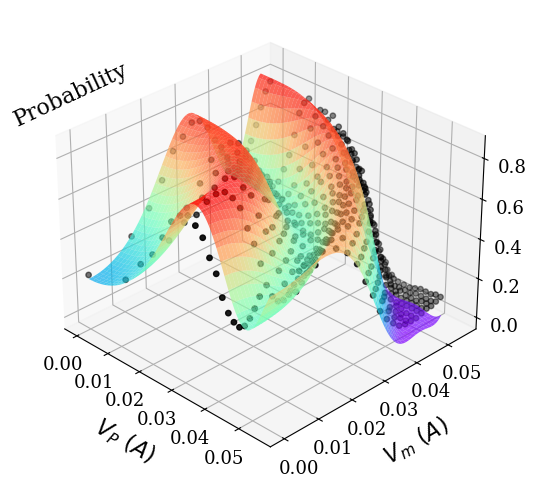

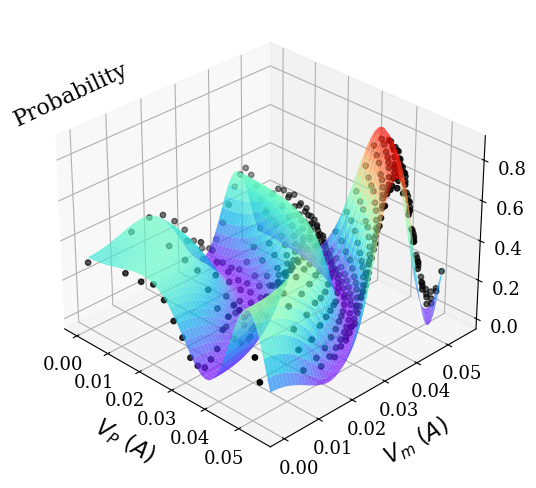

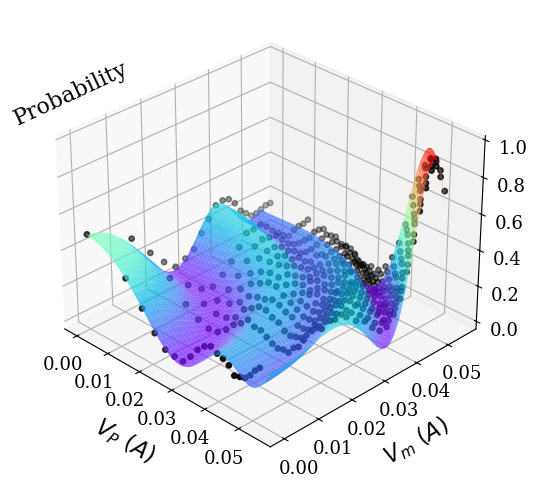

In [19]:
save = False # Set for True to generate PDFs with the plots

for outcome in range(3):
    # Set potentials
    x = np.linspace(0, 0.0551, 200)
    y = np.linspace(0, 0.0521, 200)
    X, Y = np.meshgrid(x, y)

    # Estimate probabilities from model
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i,j] = PTritterTheo(X[i,j],Y[i,j],1,outcome+1)

    # Experimental data (fix path if needed)
    path =  r"data/exp_data.txt"
    raw = np.loadtxt(path, delimiter="\t", usecols = (0,3,16,18,20))
    x_exp = np.array([i*1e-2 for i in raw[:,0]])
    y_exp = np.array([i*1e-2 for i in raw[:,1]])
    z_exp = raw[:,2+outcome]

    plt.rcParams.update({
        "text.usetex": False,        # use LaTeX
        "font.family": "DejaVu Serif",
        "font.size": 14,            # base size
        "axes.labelsize": 16,       # axis labels
        "axes.titlesize": 18,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13
    })

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    # Continuous surface from model
    surf = ax.plot_surface(
        X, Y, Z,
        cmap='rainbow',
        alpha=0.7,
        edgecolor='none'
    )

    # Experimental points
    ax.scatter(
        x_exp, y_exp, z_exp,
        color='black',
        s=15
    )
    ax.set_xlabel(r"$V_P~(A)$", labelpad = 10)
    ax.set_ylabel(r"$V_m~(A)$", labelpad = 10)
    ax.set_zlabel("")
    ax.text2D(
        -0.05, 0.75, r"Probability",
        transform=ax.transAxes,
        rotation=25,
        fontsize=16
    )
    ax.view_init(elev=30, azim=-45)
    if save:
        plt.savefig(f"Output{outcome+1}.pdf",bbox_inches="tight")

    plt.show()

## Sampling noisy data and rank analysis

The data tables are frequency matrices of shape `(20, 60)`, corresponding to a $20\times20$ grid of $(V_P, V_m)$ settings and 3 output modes (stacked as 60 columns). Each entry $D({\rm outcome}|V_P,V_m)$ is the empirical frequency of the outcome for preparation voltage $V_P$ and measurement voltage $V_m$.

**Experimental tables** (`TATritter`, `build_table`, `generate_tables`): read from the raw data file, sort by voltage, and convert coincidence counts to frequencies. The `sample=True` option in `build_table` performs multinomial resampling of each row $(C_1, C_2, C_3)$ with the same total count $N = C_1+C_2+C_3$, which generates statistically equivalent tables used to estimate $\chi^2_{\rm test}$ in the rank analysis.

**Theoretical tables** (`TheoTritter`, `build_tabletheo`, `generate_tablestheo`): evaluate `PTritterTheo` on the same $(V_P, V_m)$ grid as the experiment. The `sample=True` option generates tables by multinomial sampling from the theoretical probabilities with a chosen total count $N$, enabling a rank analysis directly on the theoretical model (as in Fig. 2A–B of the paper).

In [10]:
def TATritter():
    """
    Loads the central experimental frequency table from the raw data file.
    Sorts measurements by (V_P, V_m), extracts the three coincidence channels,
    and reshapes into a (20, 60) frequency matrix (20 V_P values x (20 V_m x 3 outputs)).
    Returns np.ndarray of shape (20, 60).
    """
    # Fix path if needed
    path = r"data/exp_data.txt"
    raw = np.loadtxt(path, delimiter="\t")
    idx = np.lexsort((raw[:, 3], raw[:, 0]))
    raw = raw[idx]
    z1 = raw[:, 16].reshape(20, 20)
    z2 = raw[:, 18].reshape(20, 20)
    z3 = raw[:, 20].reshape(20, 20)
    Z = np.stack((z1, z2, z3), axis=2)
    return Z.reshape(20, 60)


def build_table(filename, sample=False):
    """
    Builds a (20, 60) frequency table from a raw experimental data file.
    If sample=False (default), returns the central table via TATritter().
    If sample=True, performs multinomial resampling of the coincidence counts
    at each (V_P, V_m) setting, preserving the total count N per row.
    This is used to generate statistically independent realisations for
    the cross-validation step of the rank analysis.
    Returns np.ndarray of shape (20, 60).
    """
    raw = np.loadtxt(filename, delimiter="\t")
    idx = np.lexsort((raw[:, 3], raw[:, 0]))
    raw = raw[idx]
    c1=raw[:,13]; c2=raw[:,14]; c3=raw[:,15]
    C1=c1.reshape(20,20); C2=c2.reshape(20,20); C3=c3.reshape(20,20)
    if sample:
        for i in range(20):
            for j in range(20):
                C = np.array([C1[i,j],C2[i,j],C3[i,j]], dtype=int)
                N = C.sum()
                if N > 0:
                    p = C / N
                    C_new = np.random.multinomial(N, p)
                    C1[i,j],C2[i,j],C3[i,j] = C_new
        Ntot = C1+C2+C3
        with np.errstate(divide='ignore', invalid='ignore'):
            P1=np.where(Ntot>0,C1/Ntot,0)
            P2=np.where(Ntot>0,C2/Ntot,0)
            P3=np.where(Ntot>0,C3/Ntot,0)
        Z = np.stack((P1,P2,P3), axis=2)
        return Z.reshape(20, 60)
    else:
        return TATritter()


def generate_tables(filename, Nsamples=10):
    """
    Generates and saves to disk the central experimental table (index 0) and
    Nsamples-1 multinomially resampled tables (indices 1,...,Nsamples-1).
    Files are saved as 'table_sample_k.txt' with tab-separated values.
    Returns (central, samples) where central is the (20,60) central table
    and samples is a list of Nsamples-1 resampled tables.
    """
    central = build_table(filename, sample=False)
    np.savetxt("table_sample_0.txt", central, delimiter='\t', fmt='%.6f')
    samples = []
    for k in range(Nsamples-1):
        t = build_table(filename, sample=True)
        samples.append(t)
        np.savetxt(f"table_sample_{k+1}.txt", t, delimiter='\t', fmt='%.6f')
    return central, samples


def TheoTritter():
    """
    Evaluates PTritterTheo on the (V_P, V_m) grid from the experimental data file
    (arm=1 fixed), and reshapes the result into a (20, 60) probability table.
    The grid points are read from columns 0 and 3 of the data file (in mV, converted to V).
    Returns np.ndarray of shape (20, 60).
    """
    # Fix path if needed
    path = r"data/exp_data.txt"
    raw = np.loadtxt(path, delimiter="\t", usecols=(0, 3))
    p1=np.zeros(400); p2=np.zeros(400); p3=np.zeros(400)
    for i in range(400):
        p1[i]=PTritterTheo(raw[i,0]*1e-2, raw[i,1]*1e-2, 1, 1)
        p2[i]=PTritterTheo(raw[i,0]*1e-2, raw[i,1]*1e-2, 1, 2)
        p3[i]=PTritterTheo(raw[i,0]*1e-2, raw[i,1]*1e-2, 1, 3)
    for data_k, p_k in zip([None, None, None],[p1,p2,p3]):
        pass  # sorting handled below
    data1=np.column_stack((raw,p1)); idx1=np.lexsort((data1[:,1],data1[:,0])); data1=data1[idx1]
    data2=np.column_stack((raw,p2)); idx2=np.lexsort((data2[:,1],data2[:,0])); data2=data2[idx2]
    data3=np.column_stack((raw,p3)); idx3=np.lexsort((data3[:,1],data3[:,0])); data3=data3[idx3]
    Z = np.stack((data1[:,2].reshape(20,20), data2[:,2].reshape(20,20), data3[:,2].reshape(20,20)), axis=2)
    return Z.reshape(20, 60)


def build_tabletheo(sample=False, N_new=1e6):
    """
    Builds a (20, 60) theoretical frequency table.
    If sample=False, returns the exact theoretical probabilities from TheoTritter().
    If sample=True, draws multinomial samples of size N_new from the theoretical
    probabilities at each (V_P, V_m) setting, mimicking finite-statistics noise.
    N_new sets the effective number of coincidences per setting.
    Returns np.ndarray of shape (20, 60).
    """
    if sample:
        prob = TheoTritter()
        P = prob.reshape(20, 20, 3)
        C1=np.zeros((20,20)); C2=np.zeros((20,20)); C3=np.zeros((20,20))
        for i in range(20):
            for j in range(20):
                p = P[i,j]
                if np.sum(p) > 0:
                    C = np.random.multinomial(int(N_new), p)
                    C1[i,j],C2[i,j],C3[i,j] = C
        Z = np.stack((C1/N_new, C2/N_new, C3/N_new), axis=2)
        return Z.reshape(20, 60)
    else:
        return TheoTritter(2)


def generate_tablestheo(Nsamples=10):
    """
    Generates and saves to disk the central theoretical table (index 0) and
    Nsamples multinomially resampled theoretical tables (indices 1..Nsamples).
    Files are saved as 'table_theo_k.txt'.
    Returns (central, samples).
    """
    central = build_tabletheo(sample=False)
    np.savetxt("table_theo_1e3_0.txt", central, delimiter='\t', fmt='%.6f')
    samples = []
    for k in range(Nsamples):
        t = build_tabletheo(sample=True)
        samples.append(t)
        np.savetxt(f"table_theo_{k+1}.txt", t, delimiter='\t', fmt='%.6f')
    return central, samples

We can now perform the rank analysis to find the optimal $k^*$ for theory-agnostic tomography. The following functions are essentially the same as the implementation provided in [https://github.com/Albert-Aloy/NonclassicalityTests].

We run the seesaw optimisation for ranks $k = 4, \ldots, 12$ across 10 resampled data tables, and save the results to disk. (`singleshots_number`, `convergence_tolerance`) are the values used in the main text of the paper. `singleshots_number` should match the number used for poissonian sampling of the data tables.

We then load those saved results and compute:
- $\chi^2_{\rm train}$: the chi-squared of the model trained on table $a$, evaluated on the same table $a$.
- $\chi^2_{\rm test}$: the chi-squared of the model trained on table $a$, evaluated on a different table $b \neq a$ (cross-validation).
- $\Delta\chi^2_{\rm test}(k) = \chi^2_{\rm test}(k) - \chi^2_{\rm test}(k-1)$: the change in test error as rank increases. The optimal rank $k^*$ is the largest $k$ for which $\Delta\chi^2_{\rm test} < 0$.

**WARNING:** This step might take several minutes to complete. Check the capabilities of your machine before starting, and adjust `convergence_tolerance` if needed.

In [15]:
# Perform rank analysis for every sampled data table------------------------------

filename = 'trainmodel_ranks_exp.npy' # Change this filename as needed
convergence_tolerance = 1e-6 # Adjust this parameter accordingly. Convergence strongly depends on singleshots_number.
singleshots_number = 3597 # Change this number to match the N_new used in build_tabletheo

first_rank = 4; final_rank = 12
rank_length = final_rank-first_rank
run_values = range(10)
trainmodel_ranks = []
for runnum in run_values:
    print('Run: ', runnum)
    datafile = rf"data/table_sample_{runnum}.txt" # Change this path as needed
    datamat = np.genfromtxt(datafile, delimiter="\t")
    trainmodel_ranks.append(seesaw_over_range(state_optim, effect_optim_NOAB, datamat, first_rank, final_rank, singleshots_number, convergence_tolerance))

np.save(filename, np.array(trainmodel_ranks, dtype=object), allow_pickle=True)


# Estimate chi^2_train and chi^2_test---------------------------------------------
trainmodel_ranks = np.load(filename, allow_pickle=True)
first_rank=4; final_rank=12
rank_length=final_rank-first_rank
run_start=0; run_end=9
chisq_values_train = np.zeros((run_end+1, rank_length+1))
chisq_values_test  = np.zeros((run_end, run_end+1, rank_length+1))

for rank in range(first_rank, final_rank+1):
    for run in range(run_start, run_end):
        chisq_values_train[run-1, rank-first_rank] = chisquared(
            trainmodel_ranks[run-run_start][rank-first_rank],
            trainmodel_ranks[run-run_start][rank-first_rank][3], 100)
        test_index = 0
        for testrun in range(run_start, run_end):
            if testrun != run:
                test_index += 1
                testfile = rf"data/table_sample_{testrun}.txt" # Change this path as needed
                testmat = np.genfromtxt(testfile, delimiter="\t")
                chisq_values_test[test_index-1, run-1, rank-first_rank] = chisquared(trainmodel_ranks[run-run_start][rank-first_rank], testmat, 100)
chisq_mean_train=np.zeros(rank_length+1); chisq_std_train=np.zeros(rank_length+1)
chisq_mean_test =np.zeros(rank_length+1); chisq_std_test =np.zeros(rank_length+1)
for rank in range(0, final_rank-first_rank+1):
    chisq_mean_train[rank]=np.mean(chisq_values_train[:,rank])
    chisq_std_train[rank] =np.std( chisq_values_train[:,rank])
    chisq_mean_test[rank] =np.mean(chisq_values_test[:,:,rank])
    chisq_std_test[rank]  =np.std( chisq_values_test[:,:,rank])
chisq_diff=np.zeros((run_end,run_end+1,rank_length+1))
chisq_diff_av=np.zeros(rank_length+1); chisq_diff_std=np.zeros(rank_length+1)
for rank in range(0, rank_length):
    chisq_diff[:,:,rank] = chisq_values_test[:,:,rank+1]-chisq_values_test[:,:,rank]
    chisq_diff_av[rank]  = np.mean(chisq_diff[:,:,rank])
    chisq_diff_std[rank] = np.std( chisq_diff[:,:,rank])
    
# We end up with [chisq_mean_train, chisq_mean_test, chisq_std_train, chisq_std_test, chisq_diff_av, chisq_diff_std]

Run:  0
Rank = 4, iteration = 1. Current Chi^2 = 421958.1326394461
Rank = 4, iteration = 2. Current Chi^2 = 184020.63645420223
Rank = 4, iteration = 3. Current Chi^2 = 53997.4347192642
Rank = 4, iteration = 4. Current Chi^2 = 31773.061257984293
Rank = 4, iteration = 5. Current Chi^2 = 30438.76059968182
Rank = 4, iteration = 6. Current Chi^2 = 30333.19043362422
Rank = 4, iteration = 7. Current Chi^2 = 30324.68503562273
Rank = 4, iteration = 8. Current Chi^2 = 30323.996860998457
Rank = 4, iteration = 9. Current Chi^2 = 30323.94109708639
Rank = 4, iteration = 10. Current Chi^2 = 30323.936575673906
Rank = 4, iteration = 11. Current Chi^2 = 30323.9362089792
Rank = 4, iteration = 12. Current Chi^2 = 30323.936179237306
Rank = 4, iteration = 13. Current Chi^2 = 30323.936176825187
Rank = 4, iteration = 14. Current Chi^2 = 30323.936176629613
Rank = 4, iteration = 14. Converged to Chi^2 = 30323.936176629613
Rank = 5, iteration = 1. Current Chi^2 = 422069.1681633919
Rank = 5, iteration = 2. Curren

We can now reproduce the figures in the paper. It also follows the implementation in [https://github.com/Albert-Aloy/NonclassicalityTests].

In [ ]:
save = False #Change if you want to save a pdf of the plot
plt.rcParams.update({"text.usetex": True,"font.family": "serif","font.serif": ["Computer Modern Roman"]})
#======= Plot chi^2 ===============================================================================================================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(range(4,13), chisq_mean_train, yerr=chisq_std_train, fmt='o', linestyle='--', color='b', capsize=5, capthick=2, elinewidth=1, markersize=4, markeredgewidth=2, label='train error')
ax.errorbar(range(4,13), chisq_mean_test, yerr=chisq_std_test, fmt='o', linestyle='--', color='r', capsize=5, capthick=2, elinewidth=1, markersize=4, markeredgewidth=2, label='test error')
ax.set_xlabel(r'Rank $k$', fontsize=30)
ax.set_ylabel(r'$ \chi_k^2 $',fontsize=30)
ax.set_xticks([4,5,6,7,8,9,10,11,12])
ax.tick_params(axis='both', which='major', labelsize=30)
ax.yaxis.get_offset_text().set_fontsize(18)
ax.legend()
plt.legend(fontsize=18) 
ax.grid(True)

ax_inset = inset_axes(plt.gca(), width="60%", height="50%", loc='center right', borderpad=2) 
ax_inset.errorbar(range(6,13), chisq_mean_train[2:], yerr=chisq_std_train[2:], linestyle='--', color='b', fmt='o', capsize=5, capthick=2, elinewidth=1, markersize=4, markeredgewidth=2)
ax_inset.errorbar(range(6,13), chisq_mean_test[2:], yerr=chisq_std_test[2:], linestyle='--', color='r', fmt='o', capsize=5, capthick=2, elinewidth=1, markersize=4, markeredgewidth=2)
ax_inset.set_xticks([6,7,8,9,10,11,12])
ax_inset.tick_params(axis='both', which='major', labelsize=25)
ax_inset.yaxis.get_offset_text().set_fontsize(18)
ax_inset.grid(True)
if save:
    plt.savefig(f"chisq_dephased_N1e2.pdf",bbox_inches="tight")

#====== Plot Delta chi^2 =========================================================================================================================================
    plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],  # LaTeX default font
    })
    fig, ax = plt.subplots(figsize=(10, 5))

    # Main plot data
    x = range(3, 7)
    y = chisq_diff_av[:-1]
    yerr = chisq_diff_std[:-1]

    # Light uncertainty band ("shadow")
    ax.fill_between(x,y - yerr,y + yerr,color='r',alpha=0.15,linewidth=0)

    # Data + error bars
    ax.errorbar(x,y,yerr=yerr,fmt='o',linestyle='--',color='r',capsize=5,capthick=2,elinewidth=1,markersize=4,markeredgewidth=2,label='test error')

    ax.set_xlabel('Rank $k$', fontsize=30)
    ax.set_ylabel('$\Delta\chi^2_k$', fontsize=30)
    ax.set_xticks([3,4,5,6])
    ax.set_yticks([-1e7, -8000000, -6000000, -4000000, -2000000, 0])
    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.yaxis.get_offset_text().set_fontsize(18)

    ax.legend(loc='lower right',fontsize=18,framealpha=0.8)

    ax.grid(True)

    # Inset plot
    # ax_inset = inset_axes(ax,width="60%",height="50%",loc=1,borderpad=2)

    # x_in = range(6, 13)
    # y_in = chisq_diff_av[1:8]
    # yerr_in = chisq_diff_std[1:8]

    # # Inset uncertainty band
    # ax_inset.fill_between(x_in,y_in - yerr_in,y_in + yerr_in,color='r',alpha=0.15,linewidth=0)

    # # Inset data + error bars
    # ax_inset.errorbar(x_in,y_in,yerr=yerr_in,linestyle='--',color='r',fmt='o',capsize=5,capthick=2,elinewidth=1,markersize=4,markeredgewidth=2)
    # ax_inset.set_xticks([6,7,8,9,10,11,12])
    # #ax_inset.set_yticks([-10,-5,0])
    # ax_inset.tick_params(axis='both',which='major',labelsize=25)

    # ax_inset.grid(True)

    plt.savefig(
        "deltachisq_dephased_N1e6.pdf",
        bbox_inches="tight"
    )

## Nonclassicality assessment

Once we settle on the optimal rank $k^*$ for a particular set of data tables, we can investigate the nonclassicality in the set. This is done by applying the simplex-embedding linear program from Section 1 to the theory-agnostic tomographic output from Section 2, returning the robustness of contextuality averaged over the 9 resampled runs.

The tomographic output is a pair of matrices $(S, E)$ satisfying $D \approx S^T\cdot E$, with $S$ of shape `(num_preparations, k^*)` and $E$ of shape `(k^*, num_effects)`. Before feeding them to `SimplexEmbedding`, the output is renormalised using a QR + SVD decomposition that enforces the GPT normalisation convention.

In [26]:
r = np.zeros(10); r2 = np.zeros(10)
rank = 7 # Insert optimal rank value based on rank analysis
trainranks_N100 = np.load(filename, allow_pickle=True)
for i in range(10):
    state  = trainranks_N100[i][3][0].copy() # Second index translates to rank values for the rank assessment: index 0 = rank 4, index 1 = rank 5,...
    effect = trainranks_N100[i][3][1].copy()
    Drealised = np.dot(state, effect)
    Drealised = np.block([np.ones((len(Drealised),1)), Drealised.copy()])
    # QR decomposition and normalisation
    Q, R = np.linalg.qr(Drealised)
    c = Q[0,0]
    Qprime = Q/c; Rprime = c*R
    Q0 = np.array([Qprime[:,0]]).copy().T
    Q1 = np.delete(Qprime, 0, axis=1).copy()
    R0 = np.array([Rprime[0,:]]).copy()
    R1 = np.delete(Rprime, 0, axis=0).copy()
    # SVD to extract the rank-(k-1) part
    U, Sigma, V = np.linalg.svd(np.dot(Q1,R1))
    V = V.T; Sigma = np.diag(Sigma)
    U_int = U[:,0:rank-1].copy()
    Sigma_int = Sigma[0:rank-1,0:rank-1].copy()
    V_int = V[:,0:rank-1].copy()
    # Renormalised states and effects in GPT convention
    Sprealised = np.block([Q0, np.dot(U_int, np.sqrt(Sigma_int))])
    Eprealised = np.block([[R0], [np.dot(np.sqrt(Sigma_int), V_int.T)]])
    u = np.zeros(Eprealised.shape[0]); u[0] = 1
    mms = 1/20*np.sum(Sprealised, axis=0)
    r_aux = SimplexEmbedding(Sprealised.T, Eprealised, u, mms)
    r[i] = r_aux; r2[i] = r_aux**2
r_av  = np.sum(r)/10
r_std = np.sqrt(np.sum(r2 - r_av**2))/10


r_av, r_std, r, r2

(np.float64(0.20011376652926746),
 np.float64(0.004544850509993709),
 array([0.18787715, 0.20622612, 0.19526312, 0.17390862, 0.19524218,
        0.20480021, 0.19715111, 0.22867475, 0.19530139, 0.21669301]),
 array([0.03529783, 0.04252921, 0.03812768, 0.03024421, 0.03811951,
        0.04194313, 0.03886856, 0.05229214, 0.03814263, 0.04695586]))

## Sanity check — classically dephased circuit

To verify that the analysis does not spuriously certify nonclassicality from noise, we construct a classically dephased version of the circuit as introduced in Appendix C. A fully dephasing channel is inserted between the preparation and measurement stages, destroying all coherences in the computational basis:

$$\rho \mapsto \sum_i |i\rangle\langle i| \rho |i\rangle\langle i|$$

This makes the statistics classically explainable by construction. We can compute the dephased state and POVM element for given voltages and settings, and then evaluate this over the full experimental grid. As shown in Appendix C, the linear program correctly returns $r = 0$ for this classical circuit, even when multinomial noise is added, as long as the number of coincidences exceeds $N \approx 2\times10^3$.

In [2]:
def DephasedTritter(V_P, V_m, arm, output):
    """
    Computes the density matrix and POVM element for the classically dephased version
    of the tritter, where a fully dephasing channel is applied between the preparation
    and measurement unitaries. Used in the sanity check of Appendix C.

    Args:
        V_P (float): Preparation voltage (V).
        V_m (float): Measurement voltage (V).
        arm (int): Input mode in {1,2,3}.
        output (int): Output mode in {1,2,3}.

    Returns:
        float: Transition probability p(output| V_m, Depol(arm, V_P)).
    """
    state0=delta(arm,1)*np.array([1,0,0])+delta(arm,2)*np.array([0,1,0])+delta(arm,3)*np.array([0,0,1]);

    # Beam-splitters parameters
    r1=np.sqrt(0.5-0.0013112156883418314);
    t1=np.sqrt(1-r1**2);
    r2=np.sqrt(1/3-0.06608542636184132);
    t2=np.sqrt(1-r2**2);
    r3=np.sqrt(0.5-0.000988077341411374);
    t3=np.sqrt(1-r3**2);
    phitA=1.2700429167096765;
    
    # Phase-shifters parameters
    phi021 = 0.;
    phi022 = 0.;

    # Define matrices
    BS1_state = np.array([[   r1, 1j*t1, 0],
                    [1j*t1,    r1, 0],
                    [    0,     0, 1]]);
    BS2_state = np.array([[1,     0,     0],
                          [0,    r2, 1j*t2],
                          [0, 1j*t2,    r2]]);
    BS3_state = np.array([[   r3, 1j*t3, 0],
                          [1j*t3,    r3, 0],
                          [    0,     0, 1]]);
    PS1_state = np.array([[np.exp(1j*phitA), 0, 0],
                          [               0, 1, 0],
                          [               0, 0, 1]]);
    PS2_state = np.array([[1,                 0, 0],
                          [0, np.exp(1j*phi021), 0],
                          [0,                 0, 1]]);
    PS22_state = np.array([[1,                 0, 0],
                           [0, np.exp(1j*phi022), 0],
                           [0,                 0, 1]]);
    
    # Measurement stage---------------------------------------------------
    effect0=delta(output,1)*np.array([1,0,0])+delta(output,2)*np.array([0,1,0])+delta(output,3)*np.array([0,0,1]);

    # Beam-splitters parameters
    r4=np.sqrt(0.5+0.022457448732216643);
    t4=np.sqrt(1-r4**2);
    r5=np.sqrt(1/3-0.08258664403711476);
    t5=np.sqrt(1-r5**2);
    r6=np.sqrt(0.5+0.033387659875426134);
    t6=np.sqrt(1-r6**2);
    
    #Phase-shifters parameters
    phitB=0.6749525308043486;
    phi023 = 0.;
    phi024 = 0.;

    #Define matrices
    BS1_effect = np.array([[   r4, 1j*t4, 0],
                    [1j*t4,    r4, 0],
                    [    0,     0, 1]]);
    BS2_effect = np.array([[1,     0,     0],
                    [0,    r5, 1j*t5],
                    [0, 1j*t5,    r5]]);
    BS3_effect = np.array([[   r6, 1j*t6, 0],
                    [1j*t6,    r6, 0],
                    [    0,     0, 1]]);
    PS1_effect = np.array([[np.exp(1j*phitB), 0, 0],
                    [               0, 1, 0],
                    [               0, 0, 1]]);
    PS2_effect = np.array([[1,                 0, 0],
                    [0, np.exp(1j*phi023), 0],
                    [0,                 0, 1]]);
    PS22_effect = np.array([[1,                 0, 0],
                    [0, np.exp(1j*phi024), 0],
                    [0,                 0, 1]]);

    # Cross part------------------------------------------------------
    # Correction on potentials
    ar1 = 83.01198385283053;
    br1 = -94.14034493663229;
    cr12 = 0.; # No cross-talk
    ar2 = 105.36677432645476;
    br2 = -80.80041462395533;
    cr21 = 0.; # No cross-talk
    VP_eff = V_P**2*ar1/(1 - br1*V_P**2 - cr12*V_m**2)
    Vm_eff = V_m**2*ar2/(1 - br2*V_m**2 - cr21*V_P**2)
    
    alpha11 = 30.084171134830616
    alpha112 = 73.84561438057082
    alpha21 = 29.90831050462157
    alpha212 = 43.721934187266726
    alpha1211 = 0. # No cross-talk
    alpha12 = 10.2293600582318
    alpha122 = 21.88660589704521
    alpha22 = 8.545191650977921
    alpha222 = 10.70093024254361
    alpha1222 = 0. # No cross-talk
    phi01 = 0.27396751425268573
    phi02 = 0.02903291547946353
    
    phi_1 = alpha21*Vm_eff + alpha212*Vm_eff**2 + phi01 + alpha11*VP_eff + alpha112*VP_eff**2 + alpha1211*VP_eff*Vm_eff
    phi_2 = alpha22*Vm_eff + alpha222*Vm_eff**2 + phi02 + alpha12*VP_eff + alpha122*VP_eff**2 + alpha1222*VP_eff*Vm_eff

    
    PS_mode1 = np.array([[1,            0, 0],
                    [0, np.exp(1j*phi_2), 0],
                    [0,            0, 1]]);
    
    PS_mode0 = np.array([[np.exp(1j*phi_1), 0, 0],
                    [           0, 1, 0],
                    [           0, 0, 1]]);

    # Compute dephased statistics
    UTriNew_state  = BS3_state @PS22_state @BS2_state @PS1_state @PS2_state @BS1_state
    UTriNew_effect = BS3_effect@PS22_effect@BS2_effect@PS1_effect@PS2_effect@BS1_effect
    state_int  = PSx @ UTriNew_state @ state0
    effect_int = effect0.T @ UTriNew_effect @ PSy
    rho  = np.outer(state_int, np.conj(state_int))
    POVM = np.outer(np.conj(effect_int), effect_int)
    p = np.trace(POVM @ np.diag(np.diag(rho)))
    return np.abs(p)


def DephasedTheo():
    """
    Evaluates the classically dephased transition probabilities on the full experimental
    (V_P, V_m) grid (arm=1 fixed), and returns a (20, 60) probability table.
    Used to generate the classical reference data for Appendix C.
    """
    path = r"data/exp_data.txt"
    raw = np.loadtxt(path, delimiter="\t", usecols=(0, 3))
    p1=np.zeros(400); p2=np.zeros(400); p3=np.zeros(400)
    for i in range(400):
        p1[i] = DephasedTritter(raw[i,0]*1e-2, raw[i,1]*1e-2, 1, 1)
        p2[i] = DephasedTritter(raw[i,0]*1e-2, raw[i,1]*1e-2, 1, 2)
        p3[i] = DephasedTritter(raw[i,0]*1e-2, raw[i,1]*1e-2, 1, 3)
    data1=np.column_stack((raw,p1)); idx1=np.lexsort((data1[:,1],data1[:,0])); data1=data1[idx1]
    data2=np.column_stack((raw,p2)); idx2=np.lexsort((data2[:,1],data2[:,0])); data2=data2[idx2]
    data3=np.column_stack((raw,p3)); idx3=np.lexsort((data3[:,1],data3[:,0])); data3=data3[idx3]
    Z = np.stack((data1[:,2].reshape(20,20), data2[:,2].reshape(20,20), data3[:,2].reshape(20,20)), axis=2)
    return Z.reshape(20, 60)

# Acknowledgements

We thank Albert Aloy for his support with the theory-agnostic tomography functions. Some functions in this repository are inspired by the work of Jonathan Gross, Stelios Sfakianakis, and Mathew Weiss, who we hereby acknowledge. V.P.R. acknowledges support by the Digital Horizon Europe project FoQaCiA, Foundations of quantum computational advantage, GA No. 101070558, funded by the European Union, NSERC (Canada), and UKRI (UK). This work is partially carried out under IRA Programme, project no. FENG.02.01-IP.05-0006/23, financed by the FENG program 2021-2027, Priority FENG.02, Measure FENG.02.01., with the support of the FNP.

# License
## Code
The code in this notebook is licensed under the **MIT License**. You are free to use,
copy, modify, merge, publish, distribute, sublicense, and/or sell copies of it, provided
that the original copyright notice and this permission notice are included in all copies
or substantial portions of the code. See the `LICENSE` file for the full license text.

## Data
The experimental dataset (`data/exp_data.txt`) is licensed under the
**Creative Commons Attribution 4.0 International License (CC BY 4.0)**.
You are free to share and adapt the data for any purpose, provided that appropriate
credit is given to the original contributors and the associated publication [] is cited.
See [https://creativecommons.org/licenses/by/4.0/](ttps://creativecommons.org/licenses/by/4.0/) for details.
